In [10]:
# ============================================================================
# - EVALUACIÓN DE MODELOS
# ============================================================================

print("\n" + "="*60)
print("EVALUACIÓN DE MODELOS EN TEST")
print("="*60)

def evaluar_modelo(model, X_test, y_test, nombre):
    """Calcula todas las métricas de evaluación"""
    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
        roc_auc = roc_auc_score(y_test, y_proba)
    else:
        y_proba = None
        roc_auc = np.nan

    return {
        'Modelo': nombre,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc
    }, y_pred, y_proba

# Evaluar todos los modelos
resultados = []
predicciones = {}

for name, model in trained_models.items():
    print(f"\n📊 Evaluando {name}...")
    metrics, y_pred, y_proba = evaluar_modelo(model, X_test_scaled, y_test, name)
    resultados.append(metrics)
    predicciones[name] = {'pred': y_pred, 'proba': y_proba}
    print(f"   Accuracy: {metrics['Accuracy']:.4f}")
    print(f"   F1-Score: {metrics['F1-Score']:.4f}")

# Crear DataFrame de resultados
resultados_df = pd.DataFrame(resultados).round(4)
resultados_df = resultados_df.sort_values('F1-Score', ascending=False)

print("\n" + "="*60)
print("RESULTADOS FINALES (ordenados por F1-Score)")
print("="*60)
print(resultados_df.to_string(index=False))

# Guardar resultados
resultados_df.to_csv(f'{BASE}/results/metrics/comparativa_modelos.csv', index=False)
print(f"\n✅ Resultados guardados en {BASE}/results/metrics/")


EVALUACIÓN DE MODELOS EN TEST

📊 Evaluando Regresión Logística...
   Accuracy: 0.8570
   F1-Score: 0.8094

📊 Evaluando Árbol de Decisión...
   Accuracy: 0.9759
   F1-Score: 0.9651

📊 Evaluando Random Forest...
   Accuracy: 0.9831
   F1-Score: 0.9753

📊 Evaluando Gradient Boosting...
   Accuracy: 0.9818
   F1-Score: 0.9734

📊 Evaluando SVM...
   Accuracy: 0.9070
   F1-Score: 0.8687

📊 Evaluando KNN...
   Accuracy: 0.9285
   F1-Score: 0.8987

RESULTADOS FINALES (ordenados por F1-Score)
             Modelo  Accuracy  Precision  Recall  F1-Score  ROC-AUC
      Random Forest    0.9831     0.9828  0.9679    0.9753   0.9959
  Gradient Boosting    0.9818     0.9790  0.9679    0.9734   0.9972
  Árbol de Decisión    0.9759     0.9660  0.9642    0.9651   0.9731
                KNN    0.9285     0.8777  0.9208    0.8987   0.9708
                SVM    0.9070     0.8462  0.8925    0.8687   0.9599
Regresión Logística    0.8570     0.7484  0.8811    0.8094   0.9365

✅ Resultados guardados en /conten


GENERANDO GRÁFICOS


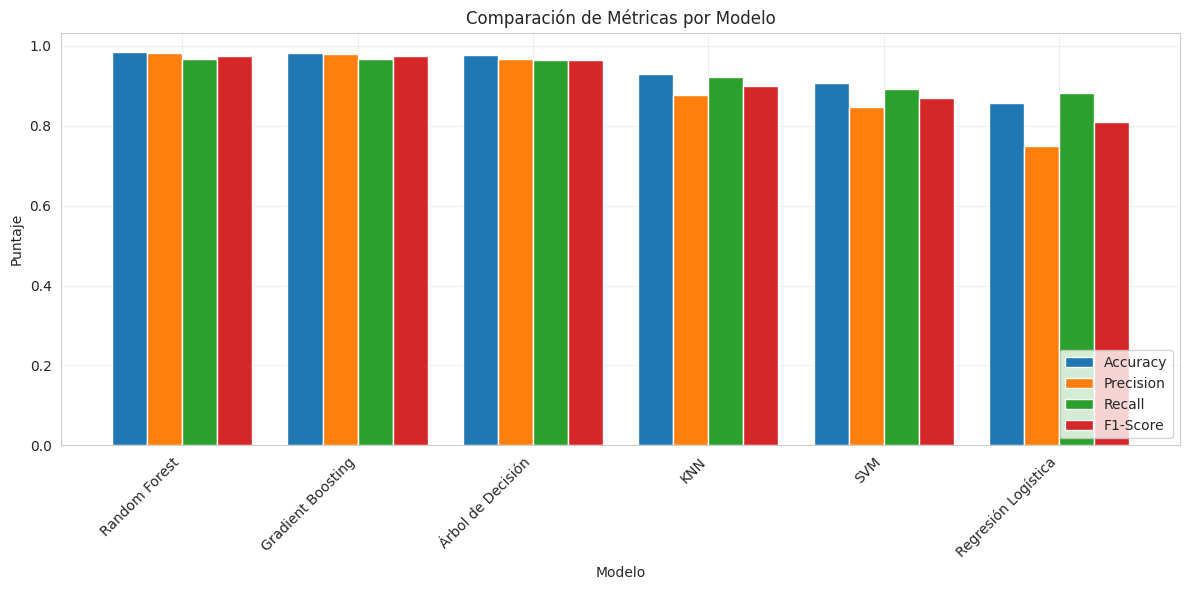

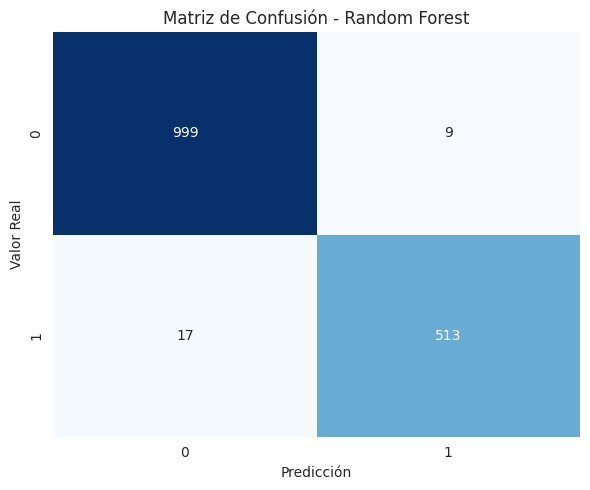

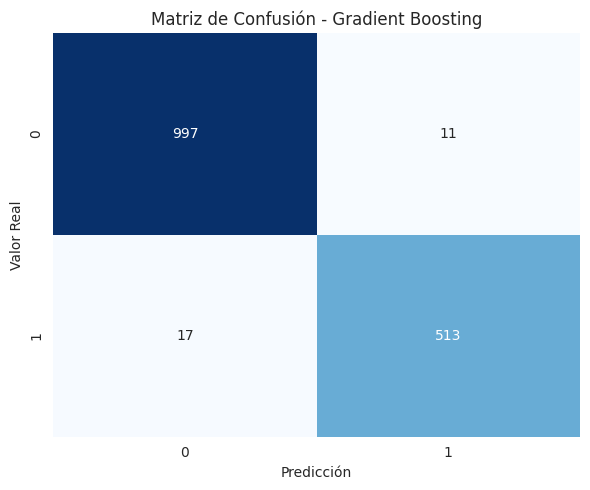

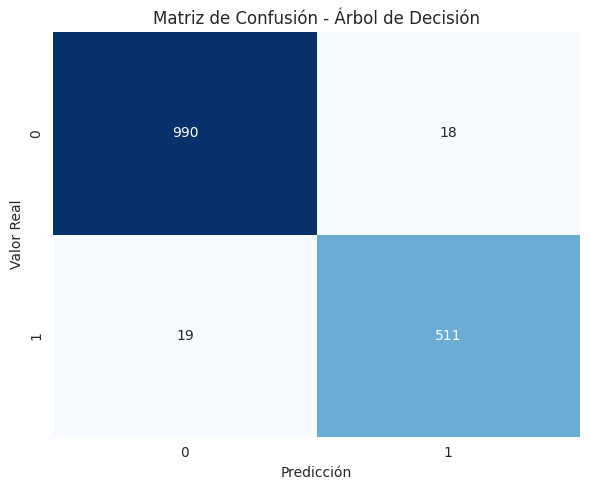

✅ Gráficos guardados en /content/drive/MyDrive/twitter_project/results/plots/


In [11]:
# ============================================================================
# VISUALIZACIONES
# ============================================================================

print("\n" + "="*60)
print("GENERANDO GRÁFICOS")
print("="*60)

# 1. Gráfico de barras comparativo
plt.figure(figsize=(12, 6))
metricas = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(resultados_df['Modelo']))
width = 0.2

for i, metrica in enumerate(metricas):
    plt.bar(x + i*width, resultados_df[metrica], width, label=metrica)

plt.xlabel('Modelo')
plt.ylabel('Puntaje')
plt.title('Comparación de Métricas por Modelo')
plt.xticks(x + width*1.5, resultados_df['Modelo'], rotation=45, ha='right')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{BASE}/results/plots/comparativa_metricas.png')
plt.show()

# 2. Matrices de confusión (top 3)
top_models = resultados_df.head(3)['Modelo'].values

for model_name in top_models:
    y_pred = predicciones[model_name]['pred']
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'Matriz de Confusión - {model_name}')
    plt.xlabel('Predicción')
    plt.ylabel('Valor Real')
    plt.tight_layout()
    plt.savefig(f'{BASE}/results/plots/matriz_confusion_{model_name}.png')
    plt.show()

print(f"✅ Gráficos guardados en {BASE}/results/plots/")